Dataset: (150, 4)

Without PCA:
ARI Score: 0.716

With PCA:
ARI Score: 0.716


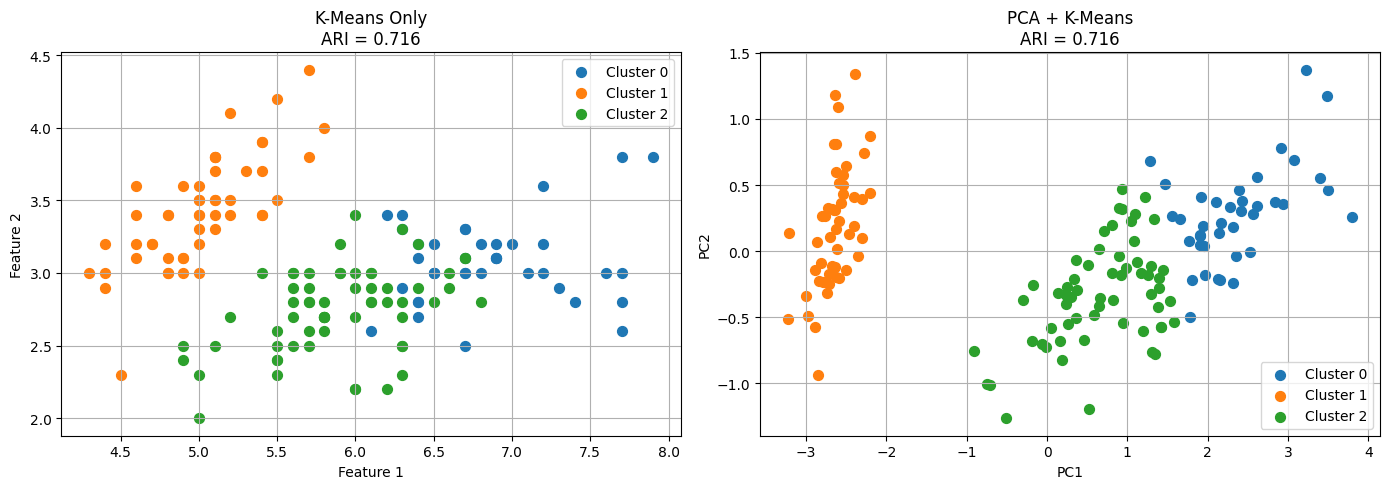

In [1]:
"""
Assignment 4: PCA + K-Means Pipeline
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import adjusted_rand_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y_true = iris.target

print("Dataset:", X.shape)

# Method 1: K-Means without PCA
kmeans_original = KMeans(n_clusters=3, random_state=42)
labels_original = kmeans_original.fit_predict(X)
ari_original = adjusted_rand_score(y_true, labels_original)

print(f"\nWithout PCA:")
print(f"ARI Score: {ari_original:.3f}")

# Method 2: PCA + K-Means Pipeline
pipeline = Pipeline([
    ('pca', PCA(n_components=2)),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])

labels_pca = pipeline.fit_predict(X)
ari_pca = adjusted_rand_score(y_true, labels_pca)

print(f"\nWith PCA:")
print(f"ARI Score: {ari_pca:.3f}")

# Get PCA transformed data for visualization
X_pca = pipeline.named_steps['pca'].transform(X)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original (using first 2 features)
for i in range(3):
    mask = labels_original == i
    axes[0].scatter(X[mask, 0], X[mask, 1], label=f'Cluster {i}', s=50)

axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title(f'K-Means Only\nARI = {ari_original:.3f}')
axes[0].legend()
axes[0].grid(True)

# Plot 2: PCA + K-Means
for i in range(3):
    mask = labels_pca == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {i}', s=50)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'PCA + K-Means\nARI = {ari_pca:.3f}')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('assignment4_pipeline.png')